In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset directly from a public URL
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Display the first 5 rows to understand what the data looks like
df.head()
df.size
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Clean Data: 'TotalCharges' is read as text. Convert to numeric and fill missing values with 0.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 2. Drop useless ID column (it has no predictive power)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# 3. Separate Features (X) and Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# 4. Convert Target 'Yes/No' into 1/0
le = LabelEncoder()
y = le.fit_transform(y)

# 5. One-Hot Encode categorical features
X = pd.get_dummies(X, drop_first=True)

print(f"Features after encoding: {X.shape[1]}")



Features after encoding: 30


In [19]:
print(X.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')


In [20]:
display(X.head())

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [21]:
# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Feature Scaling (Crucial for SVM and Logistic Regression)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data is split and scaled successfully!")

Data is split and scaled successfully!


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Initialize models
log_reg = LogisticRegression(random_state=42)
svm_model = SVC(probability=True, random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train models
print("Training Logistic Regression...")
log_reg.fit(X_train, y_train)

print("Training Support Vector Machine...")
svm_model.fit(X_train, y_train)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

print("All models trained!")

Training Logistic Regression...
Training Support Vector Machine...
Training Random Forest...
All models trained!



========== Logistic Regression ==========
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Log Loss: 0.4207 (Lower is better)
MCC Score: 0.4843 (-1 to 1, higher is better)


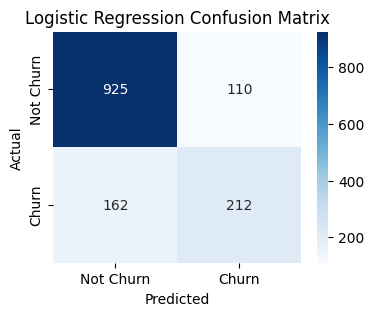


========== SVM ==========
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

Log Loss: 0.4624 (Lower is better)
MCC Score: 0.4312 (-1 to 1, higher is better)


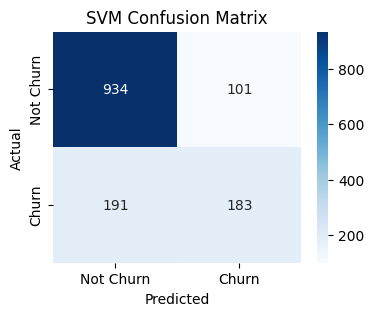


========== Random Forest ==========
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409

Log Loss: 0.5095 (Lower is better)
MCC Score: 0.4153 (-1 to 1, higher is better)


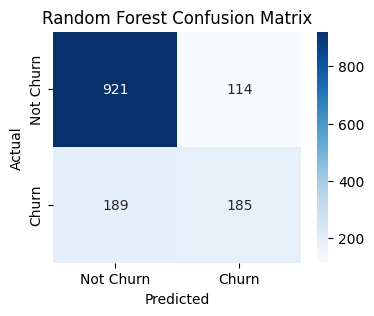

In [24]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix, log_loss, matthews_corrcoef
import seaborn as sns

models = {
    "Logistic Regression": log_reg,
    "SVM": svm_model,
    "Random Forest": rf_model
}

# Evaluate Precision, Recall, F1, plus extra metrics
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test) # Probabilities for both classes

    print(f"\n========== {name} ==========")
    print(classification_report(y_test, y_pred))

    # Calculate extra metrics
    mcc = matthews_corrcoef(y_test, y_pred)
    loss = log_loss(y_test, y_pred_prob)

    print(f"Log Loss: {loss:.4f} (Lower is better)")
    print(f"MCC Score: {mcc:.4f} (-1 to 1, higher is better)")

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Churn', 'Churn'],
                yticklabels=['Not Churn', 'Churn'])
    plt.title(f'{name} Confusion Matrix')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# --- You can leave your existing ROC Curve plotting code below this ---